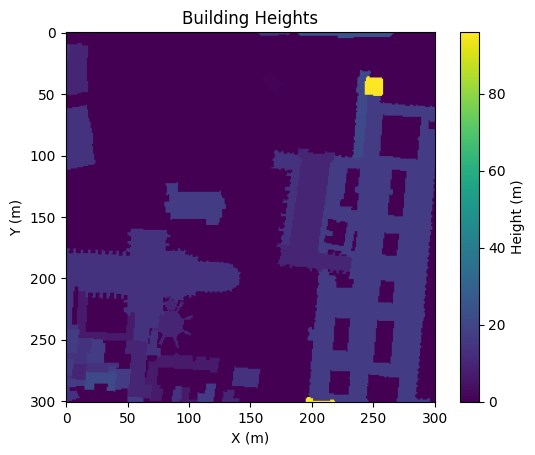

In [1]:
# visualize building height from saved building_height_map.npy

import matplotlib.pyplot as plt
import numpy as np

osm_building_height_map = np.load("../../../working-g2sm/research/examples/mobicom_result_scenes/big_ben_osm_without_lidar/2D_Building_Height_Map.npy")
plt.imshow(osm_building_height_map, cmap='viridis')
plt.colorbar(label='Height (m)')
plt.title('Building Heights')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.show()

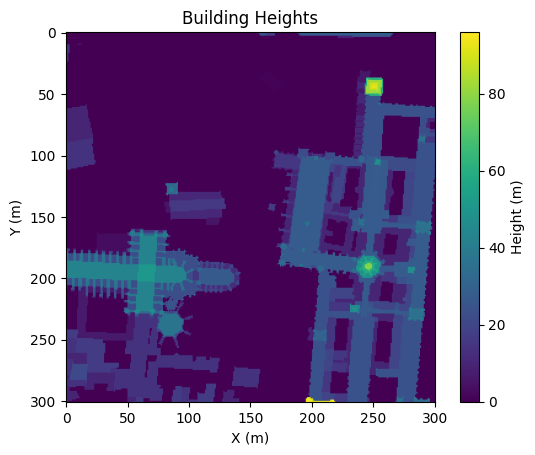

In [2]:
overture_building_height_map = np.load("../../../working-g2sm/research/examples/mobicom_result_scenes/big_ben_overture_without_lidar/2D_Building_Height_Map.npy")
plt.imshow(overture_building_height_map, cmap='viridis')
plt.colorbar(label='Height (m)')
plt.title('Building Heights')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.show()

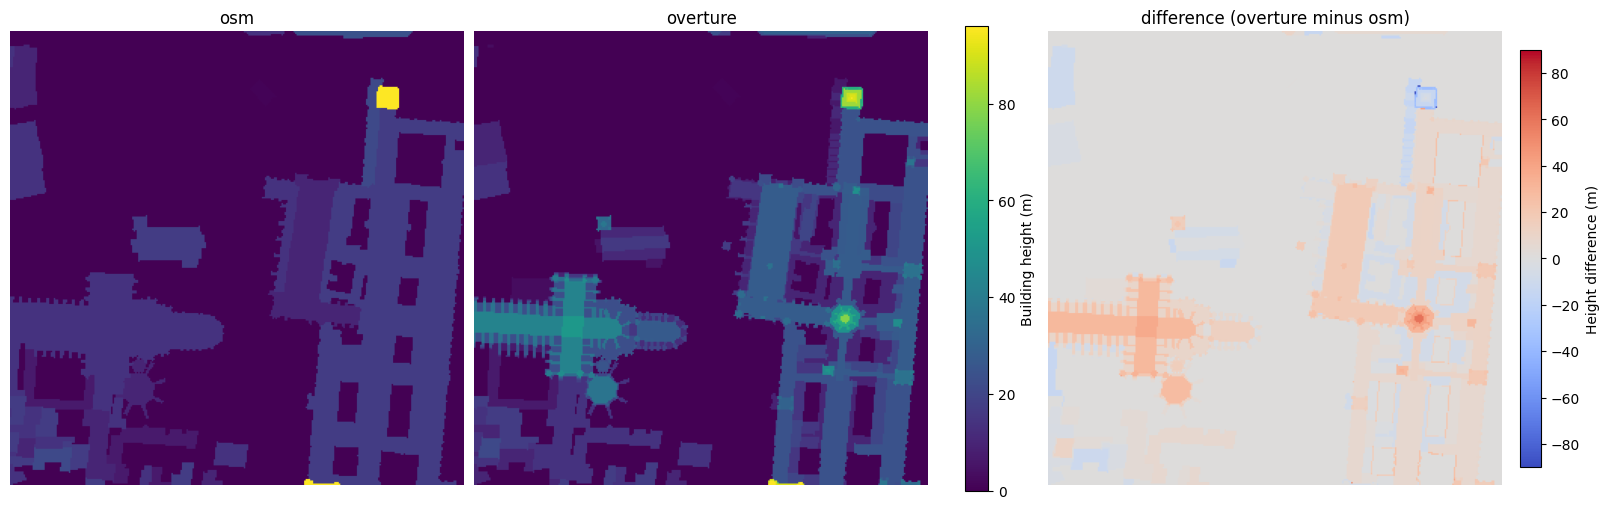

In [5]:
# Compare final building-height maps from the two modes.
osm_map = osm_building_height_map
overture_map = overture_building_height_map

diff = overture_map.astype(float) - osm_map.astype(float)

height_vmax = max(float(overture_map.max()), float(osm_map.max()), 1.0)
diff_abs_max = max(float(np.max(np.abs(diff))), 1.0) if diff.size else 1.0

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
axs[0].imshow(osm_map, cmap="viridis", vmin=0, vmax=height_vmax)
axs[0].set_title("osm")
height_im = axs[1].imshow(overture_map, cmap="viridis", vmin=0, vmax=height_vmax)
axs[1].set_title("overture")
diff_im = axs[2].imshow(diff, cmap="coolwarm", vmin=-diff_abs_max, vmax=diff_abs_max)
axs[2].set_title("difference (overture minus osm)")
height_cbar = fig.colorbar(height_im, ax=axs[:2], fraction=0.046, pad=0.04)
height_cbar.set_label("Building height (m)")
diff_cbar = fig.colorbar(diff_im, ax=axs[2], fraction=0.046, pad=0.04)
diff_cbar.set_label("Height difference (m)")
for ax in axs:
    ax.axis("off")
plt.show()